# The Physical Basis of Ocean Mass and Ocean Bottom Pressure

These notes introduce satellite gravimetry as a remote sensing method for observing changes in ocean mass. They are designed to accompany the MS 274 gravimetry lecture and follow the same notebook style as the SST notes: motivation, physical basis, simple calculations, and checks for understanding.

## Motivation

Ocean circulation redistributes water mass around the planet. When water piles up in one region and is removed from another, the mass distribution of Earth changes slightly. Satellite gravimetry uses small changes in the gravity field to infer those mass changes.

In oceanography, these measurements are often expressed as **ocean bottom pressure** because bottom pressure reflects the weight of the water column above the seafloor.

### Learning Objectives

By the end of this notebook, you should be able to:

- Explain why changes in ocean mass affect the gravity field.
- Describe the difference between ocean mass, ocean bottom pressure, and steric sea level.
- Explain why gravimetry complements satellite altimetry.
- Convert simple water-column height changes into pressure and mass changes.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


## Gravity from Point Masses

In introductory physics, gravity is often introduced as an attractive force between two point masses:

\begin{equation}
F = G\frac{m_1m_2}{r^2}
\end{equation}

where $G$ is the gravitational constant, $m_1$ and $m_2$ are masses, and $r$ is the distance between them.

Real Earth is not a single point mass. It has continents, ocean basins, mountains, ice sheets, atmosphere, and moving ocean water. A satellite in orbit feels the combined gravitational pull of all of these sources.

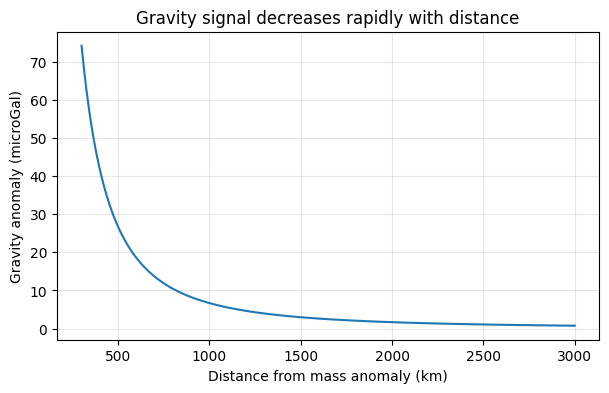

In [2]:
# Compare the gravitational acceleration from a small mass anomaly at different distances.
G = 6.67430e-11  # m^3 kg^-1 s^-2
mass_anomaly = 1e15  # kg, a simplified regional water-mass anomaly
r_km = np.linspace(300, 3000, 200)  # distance from mass anomaly, km
r_m = r_km * 1000

g_anomaly = G * mass_anomaly / r_m**2  # m s^-2
microgal = g_anomaly / 1e-8  # 1 microGal = 1e-8 m s^-2

plt.figure(figsize=(7, 4))
plt.plot(r_km, microgal)
plt.xlabel('Distance from mass anomaly (km)')
plt.ylabel('Gravity anomaly (microGal)')
plt.title('Gravity signal decreases rapidly with distance')
plt.grid(True, alpha=0.3)
plt.show()

## Gravitational Potential

The **gravitational potential** is related to the potential energy of a mass in a gravity field. For a point mass, it is commonly written as:

\begin{equation}
U = -G\frac{M}{r}
\end{equation}

A gravimetry satellite does not directly scoop up water or measure pressure at the seafloor. Instead, it responds to changes in gravitational potential and acceleration caused by changing mass distributions.

## Why Satellites Can Sense Ocean Mass

A satellite orbit is not perfectly smooth. As the spacecraft approaches a positive mass anomaly, it accelerates slightly. As it moves away, it decelerates slightly. Tracking these tiny orbital changes provides information about the gravity field.

A single satellite can be used to estimate the static gravity field. A pair of satellites flying one behind the other can provide especially sensitive measurements of changes in mass because the distance between the satellites changes as they pass over mass anomalies.

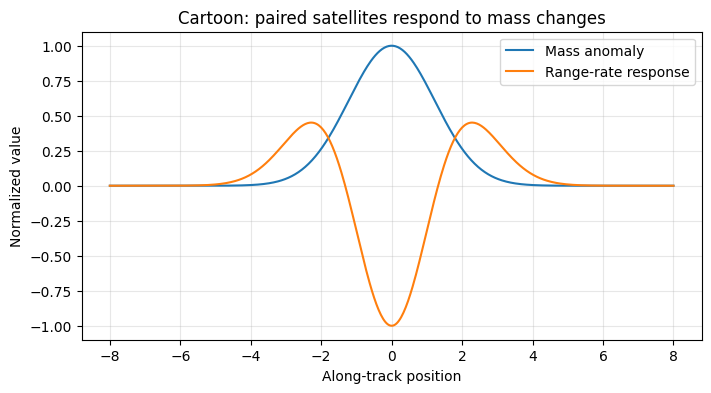

In [3]:
# A simple cartoon of how a positive mass anomaly can affect the separation of two satellites.
x = np.linspace(-8, 8, 500)
mass_signal = np.exp(-x**2 / 3.0)
# The leading satellite feels the anomaly first; the trailing satellite feels it later.
lead_response = np.gradient(np.roll(mass_signal, -25), x)
trail_response = np.gradient(np.roll(mass_signal, 25), x)
range_rate_cartoon = lead_response - trail_response

plt.figure(figsize=(8, 4))
plt.plot(x, mass_signal / mass_signal.max(), label='Mass anomaly')
plt.plot(x, range_rate_cartoon / np.max(np.abs(range_rate_cartoon)), label='Range-rate response')
plt.xlabel('Along-track position')
plt.ylabel('Normalized value')
plt.title('Cartoon: paired satellites respond to mass changes')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Ocean Bottom Pressure

Ocean bottom pressure is the pressure exerted by the weight of the water column above the seafloor. For a simple water column with density $\rho$ and height $h$,

\begin{equation}
P = \rho g h
\end{equation}

Changes in bottom pressure can therefore be interpreted as changes in the mass of the water column, as long as density and other effects are handled carefully.

In [4]:
# Convert small equivalent-water-height changes into bottom pressure anomalies.
rho0 = 1025.0  # kg m^-3, representative seawater density
g = 9.81       # m s^-2
eta_cm = np.array([-10, -5, 0, 5, 10])  # equivalent water-height anomaly, cm
eta_m = eta_cm / 100
pressure_pa = rho0 * g * eta_m
pressure_dbar = pressure_pa / 1e4  # 1 dbar is approximately 10^4 Pa

for cm, pa, db in zip(eta_cm, pressure_pa, pressure_dbar):
    print(f'{cm:+4.0f} cm water-height anomaly -> {pa:+8.1f} Pa -> {db:+.3f} dbar')

 -10 cm water-height anomaly ->  -1005.5 Pa -> -0.101 dbar
  -5 cm water-height anomaly ->   -502.8 Pa -> -0.050 dbar
  +0 cm water-height anomaly ->     +0.0 Pa -> +0.000 dbar
  +5 cm water-height anomaly ->   +502.8 Pa -> +0.050 dbar
 +10 cm water-height anomaly ->  +1005.5 Pa -> +0.101 dbar


## Mass Sea Level vs Steric Sea Level

Satellite altimetry observes total sea surface height. Gravimetry observes the mass component of sea level. These are not the same because sea level can change without adding or removing water mass.

A useful conceptual split is:

\begin{equation}
\text{total sea level} = \text{mass sea level} + \text{steric sea level}
\end{equation}

The **mass** component comes from adding or removing water. The **steric** component comes from density changes, especially thermal expansion and salinity-driven contraction or expansion.

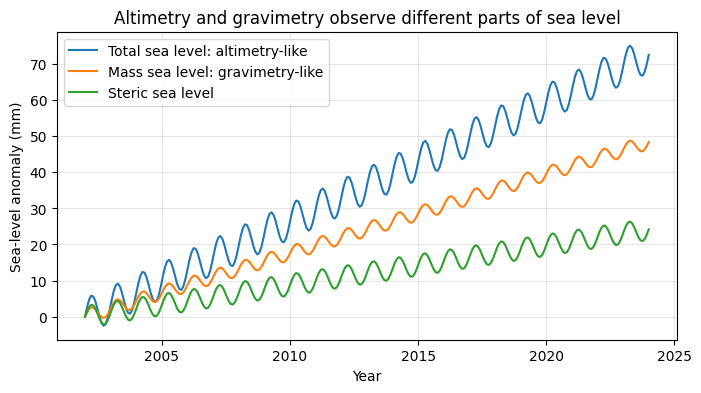

In [5]:
# Synthetic time series: total sea level can differ from mass sea level because of steric changes.
years = np.linspace(2002, 2024, 23*12)
mass_trend = 2.2 * (years - 2002)  # mm/yr contribution from added water mass
steric_trend = 1.1 * (years - 2002) # mm/yr contribution from expansion/density
seasonal = 5 * np.sin(2*np.pi*years)

mass_sl = mass_trend + 0.4 * seasonal
steric_sl = steric_trend + 0.6 * seasonal
total_sl = mass_sl + steric_sl

plt.figure(figsize=(8, 4))
plt.plot(years, total_sl, label='Total sea level: altimetry-like')
plt.plot(years, mass_sl, label='Mass sea level: gravimetry-like')
plt.plot(years, steric_sl, label='Steric sea level')
plt.xlabel('Year')
plt.ylabel('Sea-level anomaly (mm)')
plt.title('Altimetry and gravimetry observe different parts of sea level')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Check Your Understanding

1. Why does ocean mass redistribution change the gravity field?
2. Why does gravimetry not observe purely steric sea-level change?
3. If bottom pressure increases at a fixed location, what does that imply about the water column above the seafloor?

## Key Takeaways

- Satellite gravimetry observes changes in Earth's gravity field caused by moving mass.
- Ocean bottom pressure is a natural oceanographic expression of water-column mass.
- Gravimetry complements altimetry because it observes the mass component of sea-level change, while altimetry observes total sea surface height.
- Interpreting gravimetry requires removing or modeling many other sources of gravity variability, including tides, atmosphere, solid Earth effects, and static gravity.

## References and Further Reading

- MS 274 Lesson 15a slides: Gravimetry.
- Wahr, J., Molenaar, M., & Bryan, F. (1998). Time variability of the Earth's gravity field: Hydrological and oceanic effects and their possible detection using GRACE.
- Chambers, D. P., & Bonin, J. A. (2012). Evaluation of Release-05 GRACE time-variable gravity coefficients over the ocean.
- Johnson, G. C., & Chambers, D. P. (2013). Ocean bottom pressure seasonal cycles and decadal trends from GRACE Release-05.